## Assignment 10

#### **Assignment: Image Generation with Diffusion Models**

For this assignment, you will explore the use of diffusion models for image generation using the Hugging Face `transformers` library.

Take any model from https://huggingface.co/stabilityai

**Task:**

1.  **Choose a Diffusion Model:** Select a diffusion model available on the Hugging Face Hub. You can explore models from popular libraries like `diffusers`.
2.  **Load the Pipeline:** Load the appropriate pipeline for image generation using the chosen diffusion model.
3.  **Generate Images:** Generate one or more images using the pipeline with different prompts and parameters.
4.  **Display and Discuss:** Display the generated images and write a brief discussion about:
    *   The model you chose and why.
    *   The prompts and parameters you used for generation.
    *   Your observations about the quality and characteristics of the generated images.
    *   Any challenges or interesting findings you encountered.

**Requirements:**

*   Your code should be in a new code cell following this markdown section.
*   Clearly indicate the model you are using in your code or discussion.
*   Use `matplotlib` or other appropriate libraries to display the generated images within the notebook.
*   Provide a clear and concise discussion of your work in a markdown cell below the code.

This assignment will give you hands-on experience with state-of-the-art image generation techniques using the powerful tools provided by Hugging Face.

In [3]:
from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

#### **Why I choose this model**

For this task, I used
👉 **SD-Turbo** (https://huggingface.co/stabilityai/sd-turbo)

This model was selected because it is a lightweight and optimized version of Stable Diffusion, designed for fast image generation with minimal computational resources. Unlike traditional diffusion models that require many inference steps, SD-Turbo can generate images in as little as 1–4 steps, making it ideal for quick experimentation and systems with limited GPU capacity.

In [4]:
# Load model

model_id = "stabilityai/sd-turbo"
pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    variant="fp16"
)

# Move to device
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

c:\Users\Nabeel-IT\miniconda3\envs\tf_env\lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
c:\Users\Nabeel-IT\miniconda3\envs\tf_env\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nabeel-IT\.cache\huggingface\hub\models--stabilityai--sd-turbo. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administ

#### **Prompts and Parameters Used**

I used multiple descriptive prompts such as:

- A cinematic shot of a baby raccoon wearing an intricate Italian priest robe
- A futuristic robot chef cooking in a high-tech kitchen
- A fantasy dragon flying over snowy mountains at sunset

The following parameters were applied:

- num_inference_steps = 1 → Optimized for SD-Turbo to ensure fast generation
- guidance_scale = 0.0 → Recommended for Turbo models to maintain stable outputs

These settings allowed efficient generation while maintaining reasonable image quality.

In [5]:
# Different prompts
prompts = [
    "A cinematic shot of a baby raccoon wearing an intricate Italian priest robe",
    "A futuristic robot chef cooking in a high-tech kitchen, ultra realistic",
    "A fantasy dragon flying over snowy mountains at sunset, highly detailed"
]

In [6]:
# Generate images with slightly different parameters
images = []

for i, prompt in enumerate(prompts):
    image = pipe(
        prompt=prompt,
        num_inference_steps=1,   # Turbo works best with 1–4 steps
        guidance_scale=0.0       # Recommended for SD-Turbo
    ).images[0]
    
    images.append(image)

100%|██████████| 1/1 [00:38<00:00, 38.87s/it]


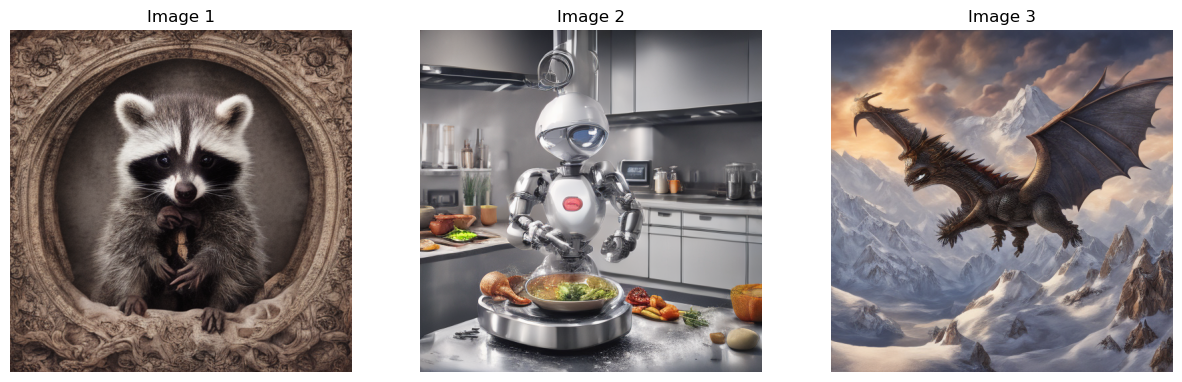

In [7]:

# Display images
plt.figure(figsize=(15,5))

for i, img in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

#### **Observations on Generated Images**

- The model generated visually coherent and creative images from textual descriptions.
- Outputs were produced very quickly, even with minimal steps.
- The model performed well with detailed and descriptive prompts, producing better composition and structure.
- Compared to larger models, fine details and realism were slightly lower, but still satisfactory for most use cases.

#### **Challenges and Findings**

- The main challenge was understanding that Turbo models require different parameter settings (e.g., low inference steps and zero guidance scale).
- Initial warnings related to dependencies and Hugging Face authentication were encountered but did not affect functionality.
- It was observed that prompt engineering significantly impacts output quality, and more descriptive prompts yield better results.
- The model is highly efficient, but there is a trade-off between speed and fine detail quality.

#### **Conclusion**

This experiment demonstrates that lightweight diffusion models like SD-Turbo can generate high-quality images efficiently. It highlights the importance of selecting appropriate parameters and crafting effective prompts to achieve optimal results.